# Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
import time

import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.spatial.distance import cdist
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score


In [2]:
np.random.seed(42)

# Собственная реализация

In [3]:
class KMeansCustom:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, n_init=10, init='kmeans++'):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol # Порог сходимости
        self.n_init = n_init # Количество запусков с разными начальными центроидами.
        self.init = init

        # Результаты лучшего запуска
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = None
        self.history_ = []

    def _euclidean_distances(self, X, centers):
        """Евклидово расстояние от каждой точки до каждого центроида.
        Возвращает матрицу (n_samples, n_clusters).
        """
        # X: (n, d), centers: (k, d)
        # broadcasting: (n,1,d) - (1,k,d) → (n,k,d) → sqrt(sum по d)
        diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]  # (n,k,d)
        return np.sqrt(np.sum(diff ** 2, axis=2))               # (n,k)

    def _init_centers_random(self, X):
        """Случайная инициализация: выбрать K точек из X без повторений."""
        indices = np.random.choice(len(X), size=self.n_clusters, replace=False)
        return X[indices].copy()

    def _init_centers_kmeans_plus_plus(self, X):
        """KMeans инициализация для лучшего начального разброса центроидов."""
        n = len(X)
        # Первый центроид — случайная точка
        first_idx = np.random.randint(0, n)
        centers = [X[first_idx].copy()]

        for _ in range(1, self.n_clusters):
            centers_arr = np.array(centers)               # (k_cur, d)
            dists = self._euclidean_distances(X, centers_arr)  # (n, k_cur)
            # Минимальное расстояние до ближайшего уже выбранного центроида
            min_dists = np.min(dists, axis=1)             # (n,)
            # Вероятность пропорциональна квадрату расстояния
            probs = min_dists ** 2
            probs /= probs.sum()
            chosen_idx = np.random.choice(n, p=probs)
            centers.append(X[chosen_idx].copy())

        return np.array(centers)

    def _assign_labels(self, X, centers):
        """Назначить каждой точке метку ближайшего центроида."""
        dists = self._euclidean_distances(X, centers)  # (n, k)
        return np.argmin(dists, axis=1)                # (n,)

    def _update_centers(self, X, labels):
        """Пересчитать центроиды как среднее точек в каждом кластере."""
        n_features = X.shape[1]
        new_centers = np.zeros((self.n_clusters, n_features))
        for k in range(self.n_clusters):
            mask = labels == k
            if mask.sum() > 0:
                new_centers[k] = X[mask].mean(axis=0)
            else:
                # Пустой кластер — переинициализируем случайной точкой
                new_centers[k] = X[np.random.randint(len(X))]
        return new_centers

    def _compute_inertia(self, X, labels, centers):
        """WCSS — сумма квадратов расстояний точек до своих центроидов."""
        inertia = 0.0
        for k in range(self.n_clusters):
            mask = labels == k
            if mask.sum() > 0:
                diff = X[mask] - centers[k]
                inertia += np.sum(diff ** 2)
        return inertia

    def _fit_once(self, X):
        """Один запуск K-Means. Возвращает (centers, labels, inertia, n_iter, history)."""
        # Инициализация
        if self.init == 'kmeans++':
            centers = self._init_centers_kmeans_plus_plus(X)
        else:
            centers = self._init_centers_random(X)

        history = [centers.copy()]
        labels = None

        for iteration in range(self.max_iter):
            # E-шаг: назначение точек кластерам
            labels = self._assign_labels(X, centers)

            # M-шаг: обновление центроидов
            new_centers = self._update_centers(X, labels)
            history.append(new_centers.copy())

            # Проверка сходимости
            shift = np.sqrt(np.sum((new_centers - centers) ** 2))
            centers = new_centers
            if shift < self.tol:
                break

        inertia = self._compute_inertia(X, labels, centers)
        return centers, labels, inertia, iteration + 1, history


    def fit(self, X):
        """Обучить модель: запустить n_init раз, сохранить лучший результат."""
        X = np.array(X, dtype=float)
        best_inertia = np.inf

        for _ in range(self.n_init):
            centers, labels, inertia, n_iter, history = self._fit_once(X)
            if inertia < best_inertia:
                best_inertia = inertia
                self.cluster_centers_ = centers
                self.labels_ = labels
                self.inertia_ = inertia
                self.n_iter_ = n_iter
                self.history_ = history

        return self

    def predict(self, X):
        """Предсказать метки кластеров для новых точек."""
        X = np.array(X, dtype=float)
        return self._assign_labels(X, self.cluster_centers_)

    def fit_predict(self, X):
        """fit + predict за один вызов."""
        return self.fit(X).labels_

# рез

In [4]:
X_blobs, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# --- Наша реализация ---
t0 = time.time()
km_custom = KMeansCustom(n_clusters=3, init='kmeans++', n_init=10)
km_custom.fit(X_blobs)

# --- Sklearn реализация ---
t0 = time.time()
km_sklearn = SklearnKMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_sklearn.fit(X_blobs)

ari_custom  = adjusted_rand_score(y_true, km_custom.labels_)
ari_sklearn = adjusted_rand_score(y_true, km_sklearn.labels_)
sil_custom  = silhouette_score(X_blobs, km_custom.labels_)
sil_sklearn = silhouette_score(X_blobs, km_sklearn.labels_)

print(f"{'Метрика':<28} {'Наш KMeans':>10} {'Sklearn':>10}")
print("-" * 50)
print(f"{'Inertia (WCSS)':<28} {km_custom.inertia_:>10.2f} {km_sklearn.inertia_:>10.2f}")
print(f"{'Adjusted Rand Index':<28} {ari_custom:>10.4f} {ari_sklearn:>10.4f}")
print(f"{'Silhouette Score':<28} {sil_custom:>10.4f} {sil_sklearn:>10.4f}")
print(f"{'Итераций':<28} {km_custom.n_iter_:>10d} {km_sklearn.n_iter_:>10d}")

Метрика                      Наш KMeans    Sklearn
--------------------------------------------------
Inertia (WCSS)                   362.79     362.79
Adjusted Rand Index              1.0000     1.0000
Silhouette Score                 0.8781     0.8781
Итераций                              2          2


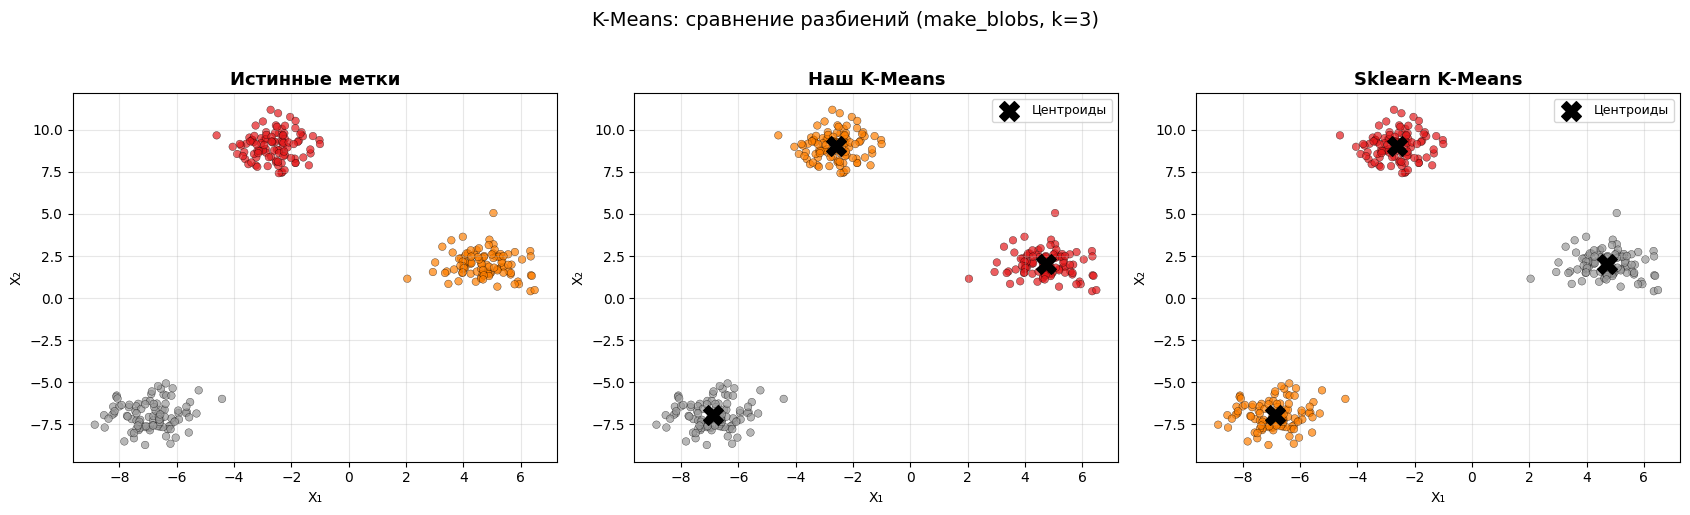

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['Истинные метки', 'Наш K-Means', 'Sklearn K-Means']
label_sets = [y_true, km_custom.labels_, km_sklearn.labels_]
centers_sets = [None, km_custom.cluster_centers_, km_sklearn.cluster_centers_]
cmap = plt.cm.Set1

for ax, title, labels, centers in zip(axes, titles, label_sets, centers_sets):
    scatter = ax.scatter(X_blobs[:, 0], X_blobs[:, 1],
                         c=labels, cmap=cmap, s=30, alpha=0.7, edgecolors='k', linewidths=0.3)
    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1],
                   c='black', s=200, marker='X', zorder=5, label='Центроиды')
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('X₁'); ax.set_ylabel('X₂')
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Means: сравнение разбиений (make_blobs, k=3)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

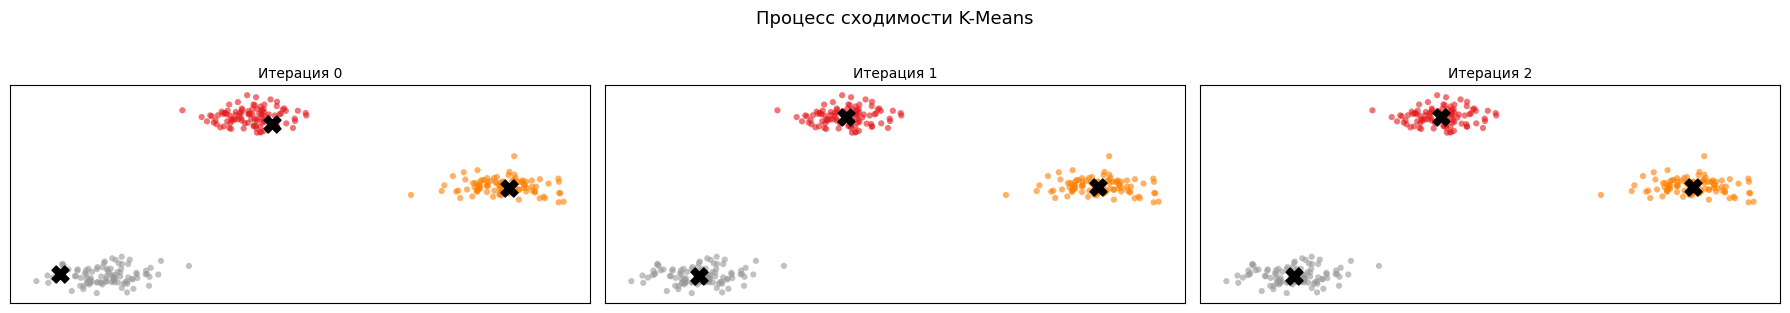

In [6]:
# Визуализация сходимости (история центроидов одного запуска)
km_trace = KMeansCustom(n_clusters=3, init='kmeans++', n_init=1, max_iter=20)
km_trace.fit(X_blobs)

n_steps = min(6, len(km_trace.history_))
step_indices = np.linspace(0, len(km_trace.history_) - 1, n_steps, dtype=int)

fig, axes = plt.subplots(1, n_steps, figsize=(18, 3))
colors = plt.cm.Set1.colors

for plot_i, step in enumerate(step_indices):
    ax = axes[plot_i]
    centers = km_trace.history_[step]
    labels_step = km_trace._assign_labels(X_blobs, centers)
    ax.scatter(X_blobs[:, 0], X_blobs[:, 1],
               c=labels_step, cmap='Set1', s=20, alpha=0.6, edgecolors='none')
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', s=150, marker='X', zorder=5)
    ax.set_title(f'Итерация {step}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Процесс сходимости K-Means', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

# Дбскан

In [7]:
class DBSCANCustom:
    # Метки для специальных состояний точек:
    # -1 — шумовая точка (не вошла ни в один кластер)
    # -2 — точка ещё не была посещена алгоритмом
    NOISE     = -1
    UNVISITED = -2

    def __init__(self, eps=0.5, min_samples=5, metric='euclidean'):
        self.eps         = eps          # радиус окрестности ε
        self.min_samples = min_samples  # мин. число соседей для корневой точки
        self.metric      = metric       # метрика расстояния

        self.labels_              = None  # метки кластеров для каждой точки
        self.core_sample_indices_ = None  # индексы корневых точек
        self.n_clusters_          = None  # итоговое число кластеров

    def _neighbors(self, dist_matrix, i):
        """Возвращает индексы всех точек в ε-окрестности точки i"""
        return np.where(dist_matrix[i] <= self.eps)[0].tolist()

    def _expand(self, i, neighbors, cluster_id, dist_matrix, labels):
        """Расширяет кластер cluster_id из корневой точки i обходом в ширину (BFS).

        добавляем в очередь всех соседей корневой точки, затем
        для каждого непосещённого соседа проверяем — является ли он
        корневым сам по себе. Если да, его соседи тоже идут в очередь.
        """
        labels[i] = cluster_id         # помечаем стартовую точку как принадлежащую кластеру
        queue = list(neighbors)        # очередь BFS: начинаем с соседей корневой точки

        while queue:
            cur = queue.pop(0)         # берём следующую точку из очереди

            if labels[cur] == self.UNVISITED:
                # Точка ещё не обработана — включаем в текущий кластер
                labels[cur] = cluster_id
                cur_nbrs = self._neighbors(dist_matrix, cur)
                if len(cur_nbrs) >= self.min_samples:
                    # Текущая точка тоже корневая — её соседи расширяют кластер
                    queue.extend(cur_nbrs)

            elif labels[cur] == self.NOISE:
                # Точка была помечена как шум, но достижима из корневой —
                # переклассифицируем как граничную (входит в кластер, но не корневая)
                labels[cur] = cluster_id

    def fit(self, X):
        X   = np.asarray(X, dtype=float)
        n   = len(X)

        # Вычисляем матрицу попарных расстояний размером n×n за один раз,
        # чтобы не пересчитывать расстояния в каждом вызове _neighbors
        D   = cdist(X, X, metric=self.metric)

        # Изначально все точки непосещены
        lbl = np.full(n, self.UNVISITED, dtype=int)

        cores, cluster_id = [], 0  # список корневых точек и счётчик кластеров

        for i in range(n):
            if lbl[i] != self.UNVISITED:
                continue  # точка уже обработана в ходе расширения чужого кластера

            nbrs = self._neighbors(D, i)

            if len(nbrs) < self.min_samples:
                # Недостаточно соседей — предварительно помечаем как шум.
                # Может быть переклассифицирована в граничную позже в _expand
                lbl[i] = self.NOISE
            else:
                # Корневая точка — запускаем новый кластер и расширяем его
                cores.append(i)
                self._expand(i, nbrs, cluster_id, D, lbl)
                cluster_id += 1

        self.labels_              = lbl
        self.core_sample_indices_ = np.array(cores)
        self.n_clusters_          = cluster_id
        return self

    def fit_predict(self, X):
        return self.fit(X).labels_



# eps задаётся в единицах расстояния между точками.
scaler = StandardScaler()

X_moons,   _ = make_moons(n_samples=300,   noise=0.08, random_state=42)
X_circles, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
X_blobs2,  _ = make_blobs(n_samples=300,   centers=3,  cluster_std=0.5, random_state=42)

noise_pts = np.random.RandomState(42).uniform(-3, 3, (20, 2))
X_blobs2  = np.vstack([X_blobs2, noise_pts])

datasets_dbscan = [
    (scaler.fit_transform(X_moons),   'Полумесяцы',           0.20, 5),
    (scaler.fit_transform(X_circles), 'Концентрические круги', 0.20, 5),
    (scaler.fit_transform(X_blobs2),  'Сгустки + шум',         0.30, 5),
]

In [8]:
PALETTE = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']

def plot_dbscan(ax, X, labels, title):
    unique = sorted(set(labels))
    n_cl   = sum(1 for l in unique if l >= 0)
    n_ns   = (labels == -1).sum()
    for lbl in unique:
        mask = labels == lbl
        if lbl == -1:
            ax.scatter(X[mask, 0], X[mask, 1], c='#BDC3C7', s=15,
                       marker='x', alpha=0.7, label='Шум', zorder=2)
        else:
            ax.scatter(X[mask, 0], X[mask, 1], c=PALETTE[lbl % len(PALETTE)],
                       s=25, alpha=0.7, label=f'Кластер {lbl}', zorder=3)
    ax.set_title(f'{title}\nКластеров: {n_cl}, шум: {n_ns}', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlabel('X₁'); ax.set_ylabel('X₂')

Датасет                    Кластеров (свой)  Кластеров (sklearn)      ARI   Время своего
--------------------------------------------------------------------------------------
Полумесяцы                                7                    7   1.0000         0.002с
Концентрические круги                    18                   18   1.0000         0.001с
Сгустки + шум                             4                    4   1.0000         0.026с


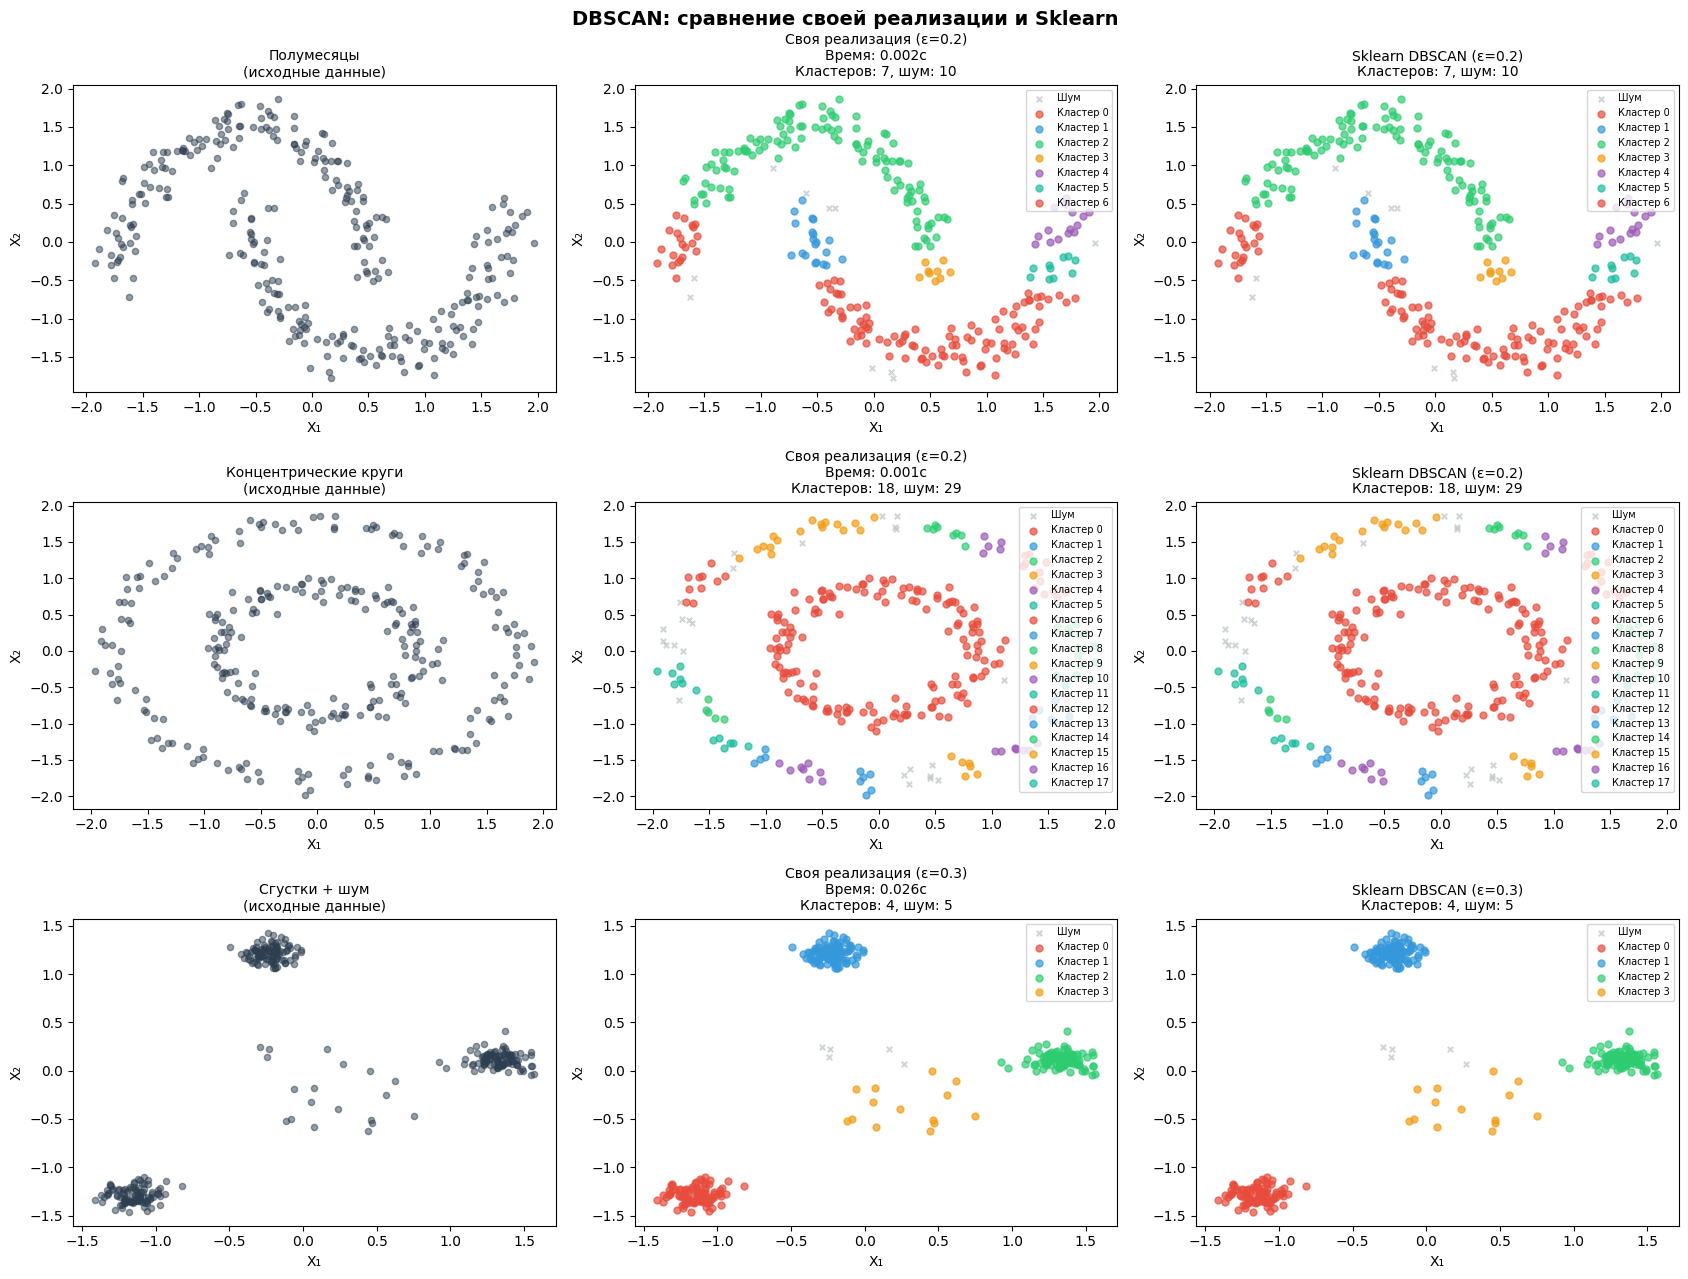

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle('DBSCAN: сравнение своей реализации и Sklearn', fontsize=14, fontweight='bold')

print(f"{'Датасет':<25} {'Кластеров (свой)':>17} {'Кластеров (sklearn)':>20} {'ARI':>8} {'Время своего':>14}")
print('-' * 86)

for row, (X, name, eps, min_s) in enumerate(datasets_dbscan):

    # исходные данные
    axes[row, 0].scatter(X[:, 0], X[:, 1], c='#2C3E50', s=20, alpha=0.5)
    axes[row, 0].set_title(f'{name}\n(исходные данные)', fontsize=10)
    axes[row, 0].set_xlabel('X₁'); axes[row, 0].set_ylabel('X₂')

    # своя реализация
    t0 = time.time()
    my_db = DBSCANCustom(eps=eps, min_samples=min_s)
    my_db.fit(X)
    t_my = time.time() - t0
    plot_dbscan(axes[row, 1], X, my_db.labels_,
                f'Своя реализация (ε={eps})\nВремя: {t_my:.3f}с')

    # sklearn
    sk_db = SklearnDBSCAN(eps=eps, min_samples=min_s)
    sk_db.fit(X)
    sk_n_cl = len(set(sk_db.labels_)) - (1 if -1 in sk_db.labels_ else 0)
    plot_dbscan(axes[row, 2], X, sk_db.labels_,
                f'Sklearn DBSCAN (ε={eps})')

    # ARI только по не-шумовым точкам
    mask_v = (my_db.labels_ != -1) & (sk_db.labels_ != -1)
    ari = adjusted_rand_score(my_db.labels_[mask_v], sk_db.labels_[mask_v]) if mask_v.sum() > 1 else float('nan')

    print(f"{name:<25} {my_db.n_clusters_:>17} {sk_n_cl:>20} {ari:>8.4f} {t_my:>13.3f}с")

plt.tight_layout()
plt.show()

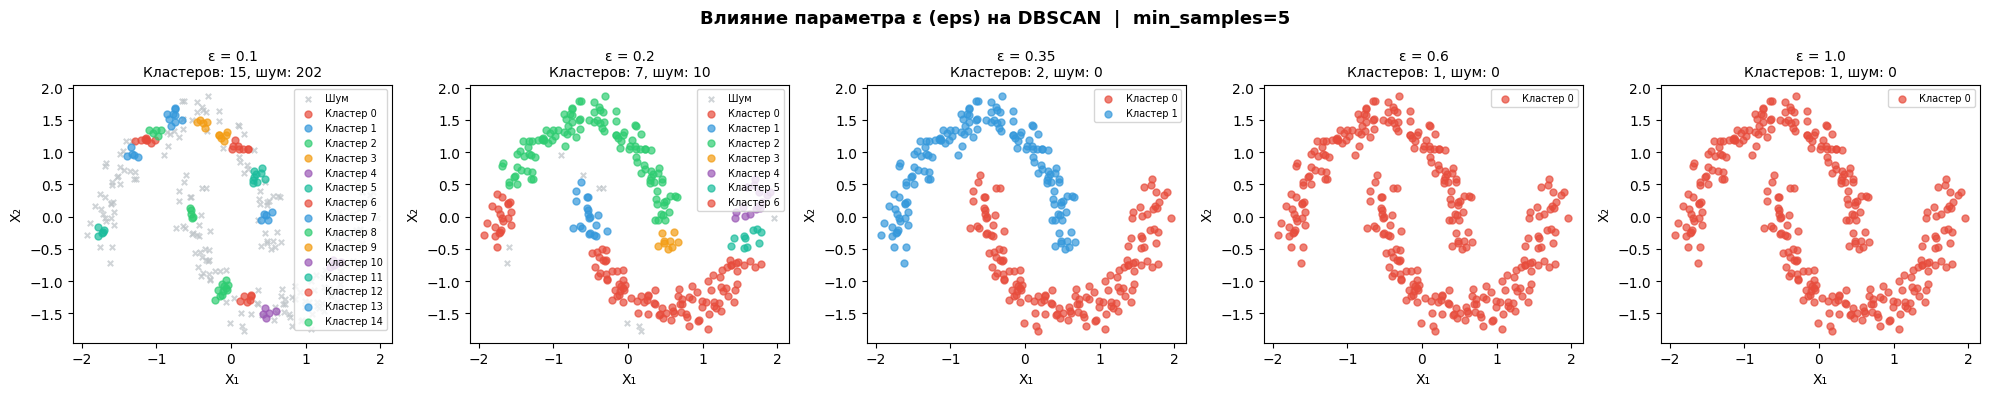

In [10]:
X_eps = scaler.fit_transform(X_moons)
eps_values = [0.1, 0.2, 0.35, 0.6, 1.0]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Влияние параметра ε (eps) на DBSCAN  |  min_samples=5', fontsize=13, fontweight='bold')

for ax, eps_val in zip(axes, eps_values):
    db = DBSCANCustom(eps=eps_val, min_samples=5)
    db.fit(X_eps)
    plot_dbscan(ax, X_eps, db.labels_, f'ε = {eps_val}')

plt.tight_layout()
plt.show()